# ATAG *Waypoint 2050* — climate analysis

Everything the reproduced scenarios say about climate, in one place: the mechanism
decomposition, the inter-edition attribution, and the contrail-mitigation variants the reports
leave out.

Figures use the AeroMAPS plot registry rather than bespoke matplotlib, so they match the rest of
the project. Committed scenario results are read back through `aeromaps.utils.results_view`,
which rebuilds a plot-compatible view from `<edition>/data_outputs/<scenario>.json` — no model
run is needed to redraw a figure. The two sections that *do* need model runs say so.

In [1]:
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeromaps import assemble_processes, create_process
from aeromaps.plots.climate_mechanisms import (
    CONTRAIL_DISABLED_NOTE,
    MECHANISM_COLORS,
    MECHANISM_GROUPS,
    group_temperature,
)
from aeromaps.utils.results_view import load_results

import utils
from utils import (
    BANDS,
    LEVELS,
    apply_non_co2_band,
    load_contrail_variants,
    load_non_co2_bands,
    load_observed,
    variant_name,
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

SCENARIOS = [
    ("3rd_edition_full", "s1", "3rd ed. S1"),
    ("3rd_edition_full", "s2", "3rd ed. S2"),
    ("2nd_edition_full", "s1", "2nd ed. S1"),
    ("2nd_edition_full", "s2", "2nd ed. S2"),
    ("2nd_edition_full", "s3", "2nd ed. S3"),
]

results = {
    (edition, scenario): load_results(
        utils.BASE / edition / "data_outputs" / f"{scenario}.json", name=label
    )
    for edition, scenario, label in SCENARIOS
}
LABEL = {(e, s): label for e, s, label in SCENARIOS}
climate = {key: view.data["climate_outputs"] for key, view in results.items()}
vectors = {key: view.data["vector_outputs"] for key, view in results.items()}

print(f"loaded {len(results)} scenarios")
print(CONTRAIL_DISABLED_NOTE)

loaded 5 scenarios

Contrail avoidance is disabled in all scenarios (operations_contrails_start_year = 2101), matching the reports' scope.

## Consistency check

Re-run the third-edition S1 scenario and compare against the committed file. A mismatch beyond
solver noise means the committed results no longer correspond to the code on this branch, and
nothing below can be trusted.

In [2]:
cwd = os.getcwd()
os.chdir(utils.BASE / "3rd_edition_full")
try:
    process = create_process("./config_files/config_s1.yaml")
    process.compute()
    recomputed = process.data["climate_outputs"]
finally:
    os.chdir(cwd)

committed = climate[("3rd_edition_full", "s1")]
worst_key, worst = None, 0.0
for column in committed.columns:
    a = committed[column].to_numpy(dtype=float)
    b = recomputed[column].to_numpy(dtype=float)
    scale = max(np.nanmax(np.abs(a)), 1e-30)
    relative = np.nanmax(np.abs(a - b)) / scale
    if relative > worst:
        worst_key, worst = column, relative

print(
    f"worst relative difference across {len(committed.columns)} series: {worst:.2e} ({worst_key})"
)
assert worst < 1e-3, f"committed results have drifted: {worst_key} off by {worst:.2e}"
print("PASS - committed climate outputs match a fresh run")

worst relative difference across 49 series: 5.12e-16 (co2_emissions)

PASS - committed climate outputs match a fresh run

## 1. Temperature and forcing, by mechanism

The climate module resolves twelve mechanisms, grouped into five families for plotting: the four
NOx terms sum to a net contribution, soot and sulfur to an aerosol term. The grouping lives in
`aeromaps.plots.climate_mechanisms`, so a mechanism keeps the same name and colour wherever it
appears.

mechanism grouping closes to the reported total exactly

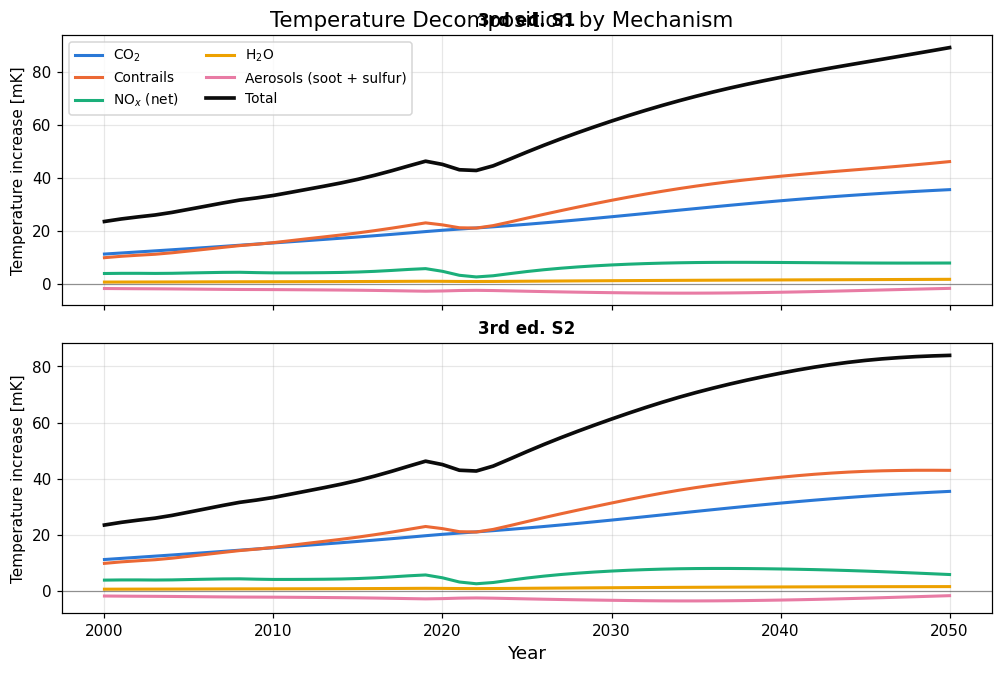

In [3]:
published = assemble_processes(
    {LABEL[key]: results[key] for key in [("3rd_edition_full", "s1"), ("3rd_edition_full", "s2")]}
)

# The grouping must close to the reported total, or the decomposition is decorative.
for key in [("3rd_edition_full", "s1"), ("3rd_edition_full", "s2")]:
    frame = climate[key]
    years = frame.index
    parts = sum(group_temperature(frame, years, group) for group in MECHANISM_GROUPS)
    assert np.allclose(parts, frame["temperature_increase_from_aviation"], rtol=0, atol=1e-12), (
        f"{LABEL[key]}: mechanism grouping does not reproduce the reported total"
    )
print("mechanism grouping closes to the reported total exactly")

published.plot("temperature_decomposition_comparison")

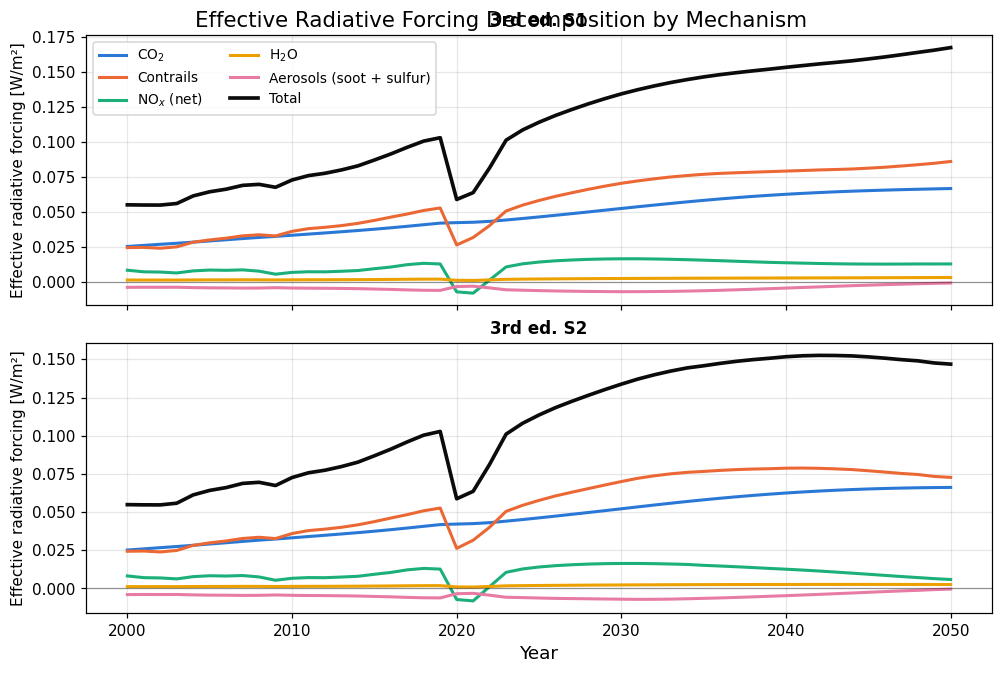

In [4]:
published.plot("erf_decomposition_comparison")

### The historic forcing is consistent with the literature

Before reading any trajectory, check the historic end against an independent number: Lee et al.
(2021) put total aviation ERF in 2018 at 100.9 mW/m².

In [5]:
LEE_2018_TOTAL_ERF_MW = 100.9  # Lee et al. (2021), total aviation ERF in 2018

erf_2018 = 1000 * climate[("3rd_edition_full", "s1")]["total_erf"].loc[2018]
deviation = erf_2018 / LEE_2018_TOTAL_ERF_MW - 1
print(f"modelled 2018 total aviation ERF : {erf_2018:.2f} mW/m2")
print(f"Lee et al. (2021)                : {LEE_2018_TOTAL_ERF_MW:.1f} mW/m2")
print(f"deviation                        : {deviation:+.1%}")
assert abs(deviation) < 0.10, (
    f"2018 ERF is {deviation:+.1%} from Lee et al. (2021); the historic forcing is not reproduced"
)
print("PASS - historic ERF is consistent with the literature")

modelled 2018 total aviation ERF : 100.36 mW/m2

Lee et al. (2021)                : 100.9 mW/m2

deviation                        : -0.5%

PASS - historic ERF is consistent with the literature

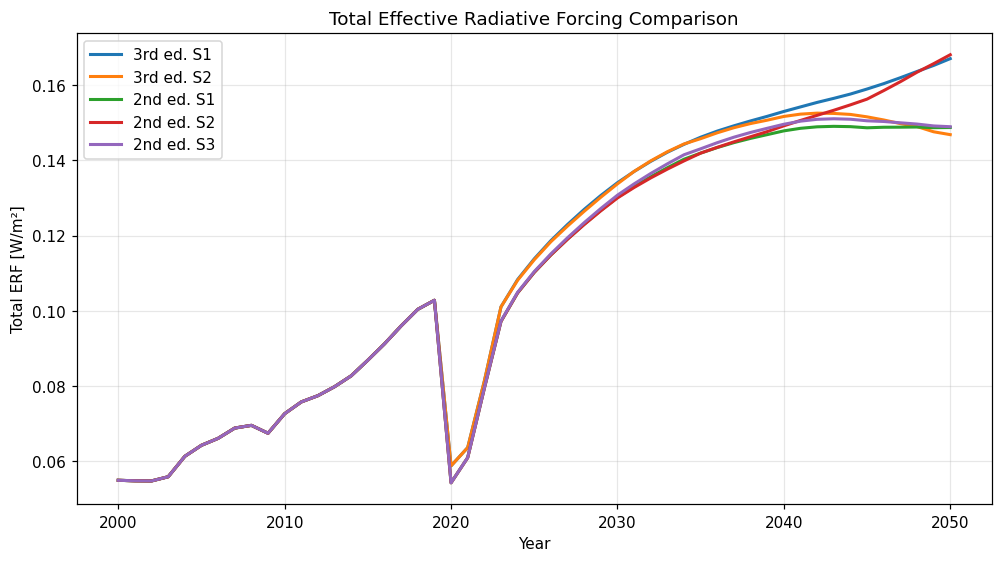

In [6]:
all_scenarios = assemble_processes({LABEL[key]: view for key, view in results.items()})
all_scenarios.plot("total_erf_comparison")

### The headline

Non-CO₂ warming exceeds CO₂ warming in 2050 in every scenario, so reaching net zero **CO₂** does
not stabilise aviation's contribution to warming.

In [7]:
rows = []
for edition, scenario, label in SCENARIOS:
    frame = climate[(edition, scenario)]
    co2 = frame["temperature_increase_from_co2_from_aviation"].loc[2050]
    non_co2 = frame["temperature_increase_from_non_co2_from_aviation"].loc[2050]
    rows.append(
        {
            "scenario": label,
            "CO2 [mK]": 1000 * co2,
            "non-CO2 [mK]": 1000 * non_co2,
            "total [mK]": 1000 * frame["temperature_increase_from_aviation"].loc[2050],
            "non-CO2 / CO2": non_co2 / co2,
        }
    )
headline = pd.DataFrame(rows).set_index("scenario").round(3)
assert (headline["non-CO2 / CO2"] > 1).all(), "non-CO2 does not dominate in every scenario"
headline

,CO2 [mK],non-CO2 [mK],total [mK],non-CO2 / CO2
scenario,,,,
3rd ed. S1,35.486,53.650,89.136,1.512
3rd ed. S2,35.455,48.509,83.965,1.368
2nd ed. S1,35.472,47.636,83.107,1.343
2nd ed. S2,35.480,52.676,88.156,1.485
2nd ed. S3,35.749,47.934,83.684,1.341


In [8]:
MECHANISMS = [
    ("CO2", "co2"),
    ("Contrails", "contrails"),
    ("NOx: short-term O3 increase", "nox_short_term_o3_increase"),
    ("NOx: long-term O3 decrease", "nox_long_term_o3_decrease"),
    ("NOx: CH4 decrease", "nox_ch4_decrease"),
    ("NOx: strat. water vapour decrease", "nox_stratospheric_water_vapor_decrease"),
    ("H2O", "h2o"),
    ("Soot", "soot"),
    ("Sulfur", "sulfur"),
]

table = pd.DataFrame(
    {
        LABEL[(e, s)]: {
            name: 1000 * climate[(e, s)][f"temperature_increase_from_{key}_from_aviation"].loc[2050]
            for name, key in MECHANISMS
        }
        for e, s, _ in SCENARIOS
    }
)
table.loc["Total"] = [
    1000 * climate[(e, s)]["temperature_increase_from_aviation"].loc[2050] for e, s, _ in SCENARIOS
]
display(table.round(3))

,3rd ed. S1,3rd ed. S2,2nd ed. S1,2nd ed. S2,2nd ed. S3
CO2,35.486,35.455,35.472,35.480,35.749
Contrails,46.080,42.959,41.830,44.283,43.934
NOx: short-term O3 increase,39.880,36.956,37.240,41.327,35.170
NOx: long-term O3 decrease,-9.731,-9.441,-9.466,-9.969,-9.330
NOx: CH4 decrease,-19.463,-18.882,-18.931,-19.939,-18.659
NOx: strat. water vapour decrease,-2.919,-2.832,-2.840,-2.991,-2.799
H2O,1.611,1.493,1.504,1.669,1.421
Soot,0.373,0.353,0.350,0.367,0.352
Sulfur,-2.179,-2.097,-2.051,-2.072,-2.155
Total,89.136,83.965,83.107,88.156,83.684


### Cross-edition pairing

The editions renamed and swapped their scenarios: the third edition's S1 descends from the second
edition's S2 and vice-versa. Analogous scenarios must therefore be paired explicitly rather than
by name — and the pairing is checked, not assumed.

In [9]:
deltas = {}
for third, second in utils.ANALOGOUS.items():
    a, b = climate[third], climate[second]
    deltas[f"{LABEL[third]} - {LABEL[second]}"] = {
        name: 1000
        * (
            a[f"temperature_increase_from_{key}_from_aviation"].loc[2050]
            - b[f"temperature_increase_from_{key}_from_aviation"].loc[2050]
        )
        for name, key in MECHANISMS
    }
delta_table = pd.DataFrame(deltas)
delta_table.loc["Total"] = [
    1000
    * (
        climate[t]["temperature_increase_from_aviation"].loc[2050]
        - climate[s]["temperature_increase_from_aviation"].loc[2050]
    )
    for t, s in utils.ANALOGOUS.items()
]

for third, second in utils.ANALOGOUS.items():
    other = next(v for k, v in utils.ANALOGOUS.items() if k != third)
    value = climate[third]["temperature_increase_from_aviation"].loc[2050]
    near = abs(value - climate[second]["temperature_increase_from_aviation"].loc[2050])
    far = abs(value - climate[other]["temperature_increase_from_aviation"].loc[2050])
    assert near < far, (
        f"{LABEL[third]} is closer to {LABEL[other]} than to {LABEL[second]}; "
        "the cross-edition pairing does not hold"
    )
print("PASS - cross-edition pairing holds (3rd S1 <-> 2nd S2, 3rd S2 <-> 2nd S1)")
display(delta_table.round(3))

PASS - cross-edition pairing holds (3rd S1 <-> 2nd S2, 3rd S2 <-> 2nd S1)

,3rd ed. S1 - 2nd ed. S2,3rd ed. S2 - 2nd ed. S1
CO2,0.006,-0.016
Contrails,1.797,1.129
NOx: short-term O3 increase,-1.447,-0.284
NOx: long-term O3 decrease,0.238,0.025
NOx: CH4 decrease,0.476,0.049
NOx: strat. water vapour decrease,0.071,0.007
H2O,-0.058,-0.011
Soot,0.005,0.004
Sulfur,-0.107,-0.046
Total,0.980,0.857


## 2. Observed versus reproduced traffic

The scenarios take observed traffic through 2023 and predict from 2024 onwards, so 2024 is the
first genuinely forecast year. Observations are overlaid on the standard comparison plot, the
same way the validation notebooks overlay digitised report data.

worst |error| over the observed years 2020-2023 : 2.22e-16

first prospective year (2024) error            : -0.89%

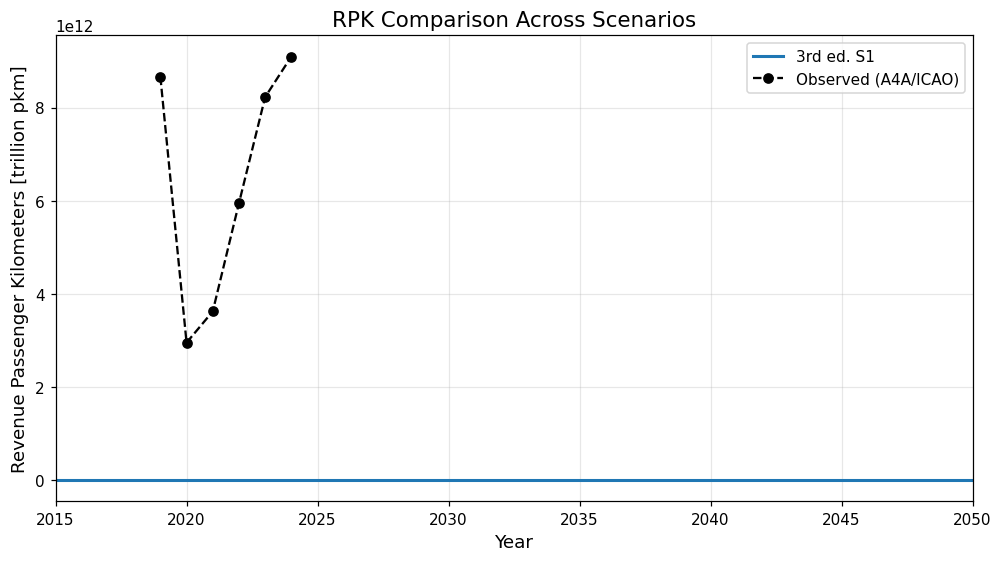

In [10]:
observed = load_observed()
years = list(range(2019, 2025))
model_rpk = vectors[("3rd_edition_full", "s1")]["rpk"].reindex(years)
observed_rpk = observed["rpk"].reindex(years)

plot_rpk = assemble_processes({"3rd ed. S1": results[("3rd_edition_full", "s1")]}).plot(
    "rpk_comparison"
)
plot_rpk.ax.plot(years, observed_rpk, "o--", color="black", label="Observed (A4A/ICAO)")
plot_rpk.ax.set_xlim(2015, 2050)
plot_rpk.ax.legend()

worst_historic = max(
    abs(model_rpk.loc[year] / observed_rpk.loc[year] - 1) for year in years if 2020 <= year < 2024
)
print(f"worst |error| over the observed years 2020-2023 : {worst_historic:.2e}")
print(
    f"first prospective year (2024) error            : "
    f"{model_rpk.loc[2024] / observed_rpk.loc[2024] - 1:+.2%}"
)
assert worst_historic < 1e-9, "observed years are not reproduced exactly"

## 3. Attributing the inter-edition difference

The third edition revised four things that can move the 2050 temperature outcome: the technology
improvement path, the operations gain, the offset treatment, and the SAF mandates. Each swap is
applied on its own against the third-edition S1 baseline, so contributions are individually
attributable; the interaction residual measures how far that construction can be trusted.

There is also a **fifth difference, and it is structural rather than a lever**: the third edition
runs from a 2024 prospection baseline anchored on observed traffic through 2023, while the second
edition runs from 2020 as published. That cannot be applied as a parameter swap, so it shows up as
the part of the inter-edition gap the four swaps do not explain — and it turns out to dominate.

**This section runs the model** — six scenarios.

In [11]:
THIRD = utils.BASE / "3rd_edition_full"
HERE = utils.BASE / "climate_analysis"

MARKETS = ["short_range", "medium_range", "long_range"]
TECH_2ND = [0.3, 0.5, 1.6, 1.3]
OPERATIONS_2ND = {"operations_gain_reference_years_values": [0, 3]}
OFFSET_2ND = {
    "residual_carbon_offset_share_reference_years": [2020, 2035, 2050],
    "residual_carbon_offset_share_reference_years_values": [0.0, 0.0, 100.0],
    # The second edition has no prescribed CORSIA path; a flat zero series
    # reproduces its absence without removing the parameter.
    "manual_carbon_offset_reference_years": [2020, 2050],
    "manual_carbon_offset_reference_years_values": [0.0, 0.0],
    "carbon_offset_baseline_level_vs_corsia_reference_year_reference_periods_values": [100.0],
}


def run(config_dir, config_name, overrides=None):
    """Run one scenario with optional parameter overrides; return its outputs."""
    cwd = os.getcwd()
    os.chdir(config_dir)
    try:
        process = create_process(f"./config_files/{config_name}")
        for key, value in (overrides or {}).items():
            setattr(process.parameters, key, value)
        process.compute()
        return process.data["climate_outputs"].copy(), process.data["vector_outputs"].copy()
    finally:
        os.chdir(cwd)


def tech_override(values):
    return {
        f"{market}_energy_per_ask_dropin_fuel_gain_reference_years_values": list(values)
        for market in MARKETS
    }


runs = {}
runs["baseline (3rd ed. S1)"] = run(THIRD, "config_s1.yaml")
runs["technology -> 2nd ed."] = run(THIRD, "config_s1.yaml", tech_override(TECH_2ND))
runs["operations -> 2nd ed."] = run(THIRD, "config_s1.yaml", OPERATIONS_2ND)
runs["offsets -> 2nd ed."] = run(THIRD, "config_s1.yaml", OFFSET_2ND)
runs["SAF -> 2nd ed."] = run(HERE, "config_s1_saf_2nd_edition.yaml")
runs["all four -> 2nd ed."] = run(
    HERE,
    "config_s1_saf_2nd_edition.yaml",
    {**tech_override(TECH_2ND), **OPERATIONS_2ND, **OFFSET_2ND},
)

T = "temperature_increase_from_aviation"
reference = climate[("2nd_edition_full", "s2")]
baseline_t = runs["baseline (3rd ed. S1)"][0][T].loc[2050]
print(f"3rd ed. S1 (baseline) : {1000 * baseline_t:.3f} mK")
print(f"2nd ed. S2 (target)   : {1000 * reference[T].loc[2050]:.3f} mK")
print(f"difference to explain : {1000 * (reference[T].loc[2050] - baseline_t):+.3f} mK")

3rd ed. S1 (baseline) : 89.136 mK

2nd ed. S2 (target)   : 88.156 mK

difference to explain : -0.980 mK

In [12]:
rows = [
    {"swap": name, "dT2050 [mK]": 1000 * (clim[T].loc[2050] - baseline_t)}
    for name, (clim, _) in runs.items()
    if not name.startswith("baseline")
]
attribution = pd.DataFrame(rows).set_index("swap")
individual = attribution.loc[
    ["technology -> 2nd ed.", "operations -> 2nd ed.", "SAF -> 2nd ed.", "offsets -> 2nd ed."],
    "dT2050 [mK]",
]
combined = attribution.loc["all four -> 2nd ed.", "dT2050 [mK]"]
residual = combined - individual.sum()

attribution.loc["sum of individual swaps"] = individual.sum()
attribution.loc["interaction residual"] = residual
display(attribution.round(4))

print(f"sum of individual swaps : {individual.sum():+.4f} mK")
print(f"full swap               : {combined:+.4f} mK")
print(
    f"interaction residual    : {residual:+.4f} mK "
    f"({abs(residual / combined):.1%} of the full swap)"
)

gap = 1000 * (reference[T].loc[2050] - baseline_t)
baseline_effect = gap - combined
print(f"inter-edition gap       : {gap:+.3f} mK")
print(f"explained by the levers : {combined:+.3f} mK")
print(f"left to the baseline    : {baseline_effect:+.3f} mK  (2024 observed vs 2020 published)")

# The four swaps are lever revisions; the baseline year is not a lever and cannot be
# swapped as a parameter, so it is reported rather than asserted away. What is worth
# asserting is that the ceteris paribus construction holds together: the interaction
# between the swaps stays small next to the swaps themselves.
assert abs(residual) < 0.5 * max(abs(individual).max(), 1e-9), (
    "the individual swaps interact too strongly to be read one at a time"
)
print("PASS - swaps are near-separable; the baseline change is reported separately")

,dT2050 [mK]
swap,
technology -> 2nd ed.,0.8883
operations -> 2nd ed.,1.0542
offsets -> 2nd ed.,0.0000
SAF -> 2nd ed.,-1.3416
all four -> 2nd ed.,0.6584
sum of individual swaps,0.6010
interaction residual,0.0575


sum of individual swaps : +0.6010 mK

full swap               : +0.6584 mK

interaction residual    : +0.0575 mK (8.7% of the full swap)

inter-edition gap       : -0.980 mK

explained by the levers : +0.658 mK

left to the baseline    : -1.638 mK  (2024 observed vs 2020 published)

PASS - swaps are near-separable; the baseline change is reported separately

### The offset finding

Offsets are accounted outside the physical emissions stream: they reduce the *reported* net
figure without changing what leaves an engine. The climate module is driven by physical
emissions, so swapping the entire offset treatment should move the temperature trajectory by
exactly nothing — which is itself a statement about what offsets can and cannot do.

In [13]:
baseline_clim, baseline_vec = runs["baseline (3rd ed. S1)"]
offset_clim, offset_vec = runs["offsets -> 2nd ed."]

print(
    f"cumulative offsets, 3rd ed. treatment : "
    f"{baseline_vec['cumulative_carbon_offset'].iloc[-1]:.3f} Gt"
)
print(
    f"cumulative offsets, 2nd ed. treatment : "
    f"{offset_vec['cumulative_carbon_offset'].iloc[-1]:.3f} Gt"
)

difference = (offset_clim[T] - baseline_clim[T]).abs().max()
print(f"largest temperature difference over 1940-2050: {difference:.3e} K")
assert difference == 0.0, (
    "the offset swap changed the temperature trajectory; offsets are no longer outside the "
    "physical emissions stream"
)
print(
    "PASS - changing the entire offset treatment moves the temperature trajectory by exactly zero"
)

cumulative offsets, 3rd ed. treatment : 6.713 Gt

cumulative offsets, 2nd ed. treatment : 8.374 Gt

largest temperature difference over 1940-2050: 0.000e+00 K

PASS - changing the entire offset treatment moves the temperature trajectory by exactly zero

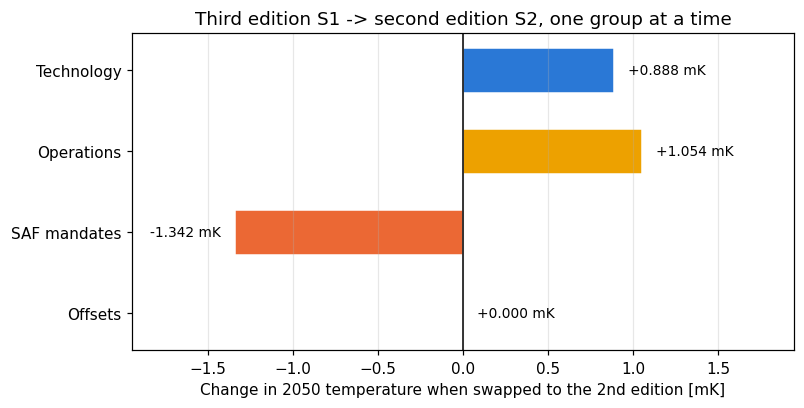

In [14]:
order = ["technology -> 2nd ed.", "operations -> 2nd ed.", "SAF -> 2nd ed.", "offsets -> 2nd ed."]
labels = ["Technology", "Operations", "SAF mandates", "Offsets"]
values = [attribution.loc[key, "dT2050 [mK]"] for key in order]
colours = [MECHANISM_COLORS[k] for k in ("co2", "h2o", "contrails", "nox")]

fig, ax = plt.subplots(figsize=(7.2, 3.6), layout="constrained")
bars = ax.barh(
    np.arange(len(order)), values, height=0.56, color=colours, edgecolor="white", linewidth=1.0
)
pad = 0.06 * max(abs(min(values)), abs(max(values)), 1e-9)
for rect, value in zip(bars, values):
    ax.text(
        value + (pad if value >= 0 else -pad),
        rect.get_y() + rect.get_height() / 2,
        f"{value:+.3f} mK",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9,
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Change in 2050 temperature when swapped to the 2nd edition [mK]")
ax.set_title("Third edition S1 -> second edition S2, one group at a time")
ax.grid(True, alpha=0.3, axis="x")
span = max(abs(min(values)), abs(max(values)))
ax.set_xlim(-1.45 * span, 1.45 * span)
plt.show()

### Technology interpolation across the prospection boundary

The technology gain curves are anchored at 2019, which now sits inside the observed period.
Historic energy intensity is data rather than model output, so a discontinuity at the boundary
would mean the calibration is fighting the observations.

In [15]:
_, vec = runs["baseline (3rd ed. S1)"]
intensity = vec["energy_consumption"] / vec["ask"]

print("energy intensity [MJ/ASK]")
for year in [2021, 2022, 2023, 2024, 2025, 2026]:
    marker = "  <- first prospective year" if year == 2024 else ""
    print(f"  {year}  {intensity.loc[year]:.4f}{marker}")

step = abs(intensity.loc[2024] / intensity.loc[2023] - 1)
typical = abs(intensity.loc[2026] / intensity.loc[2025] - 1)
print(f"year-on-year change at the boundary : {step:.3%}")
print(f"typical prospective year-on-year    : {typical:.3%}")
assert step < 0.05, "energy intensity jumps at the prospection boundary"
print("PASS - intensity is continuous across the boundary")

energy intensity [MJ/ASK]

  2021  1.1924

  2022  1.1842

  2023  1.1758

  2024  1.1605  <- first prospective year

  2025  1.1520

  2026  1.1433

year-on-year change at the boundary : 1.304%

typical prospective year-on-year    : 0.752%

PASS - intensity is continuous across the boundary

## 4. Contrail mitigation variants

The reports leave contrail mitigation out entirely — every scenario runs with
`operations_contrails_start_year = 2101`, which switches the lever off. Contrails are
nonetheless the largest single warming term in 2050, so these variants quantify what is being
left out. Parameters follow Teoh et al. (2020); see `contrail_variants.yaml`.

**This section runs the model** — ten scenarios.

In [16]:
BASELINE = "No mitigation (as reported)"
contrail_reference, families = load_contrail_variants()
print(f"source: {contrail_reference['citation'].strip()}")
print(f"doi   : {contrail_reference['doi']}")
for key, family in families.items():
    gains = [family["levels"][level]["operations_contrails_final_gain"] for level in LEVELS]
    start = family["levels"]["Central"]["operations_contrails_start_year"]
    print(f"  {family['label']:<34} from {start}  gain {gains} %")

# The mitigation levels and the non-CO2 bands are both named by climate impact, so a variant
# named "High" means one coherent pessimistic case: largest contrail forcing, weakest benefit
# from cleaner fuel, and the weakest end of Teoh's confidence interval on the mitigation itself.
band_reference, bands, pairing = load_non_co2_bands()
print()
print(f"non-CO2 bands: {', '.join(bands[k]['label'] for k in BANDS)}")
for level, key in zip(LEVELS, BANDS):
    b = bands[key]
    print(
        f"  {level:<8} -> sensitivity_rf {b['sensitivity_rf']:.3g}, "
        f"SAF contrail reduction {b['implied_saf_contrail_reduction_percent']:.1f} %"
    )

source: Teoh et al. (2020), Mitigating the Climate Forcing of Aircraft Contrails by Small-Scale Diversions and Technology Adoption, Environ. Sci. Technol.

doi   : 10.1021/acs.est.9b05608

  Low-risk diversion                 from 2030  gain [23.0, 20.0, 17.4] %

  Small-scale diversion              from 2030  gain [65.6, 59.3, 52.4] %

  Long-term combustor technology     from 2035  gain [82.1, 68.8, 45.2] %

non-CO2 bands: Low non-CO2, Central, High non-CO2

  Low      -> sensitivity_rf 9.2e-13, SAF contrail reduction 50.0 %

  Central  -> sensitivity_rf 2.23e-12, SAF contrail reduction 36.8 %

  High     -> sensitivity_rf 3.54e-12, SAF contrail reduction 15.0 %

In [17]:
cwd = os.getcwd()
os.chdir(utils.BASE / "3rd_edition_full")
try:
    contrail_processes = {BASELINE: create_process("./config_files/config_s1.yaml")}
    # A no-mitigation run at each band. The variants now move the band as well as the
    # mitigation gain, so "avoided warming" is only meaningful against a baseline at the
    # same band -- otherwise the band's own reduction in contrail forcing is counted as
    # if the mitigation had achieved it.
    baseline_by_band = {}
    for band_key in BANDS:
        reference_process = create_process("./config_files/config_s1.yaml")
        apply_non_co2_band(reference_process, bands[band_key])
        reference_process.compute()
        baseline_by_band[band_key] = reference_process.data["climate_outputs"]
    for key, family in families.items():
        for level in LEVELS:
            process = create_process("./config_files/config_s1.yaml")
            for parameter, value in family["levels"][level].items():
                setattr(process.parameters, parameter, value)
            # Same level name, same climate-impact end: the variant and the non-CO2 band
            # move together rather than multiplying into a 3x3 grid.
            apply_non_co2_band(process, bands[BANDS[LEVELS.index(level)]])
            contrail_processes[variant_name(family["label"], level)] = process

    contrails = assemble_processes(contrail_processes)
    contrails.compute_all()
finally:
    os.chdir(cwd)

# Only the families are declared as groups. The baseline is left ungrouped, so it is drawn as a
# plain reference line rather than a degenerate one-member envelope.
groups = {
    family["label"]: [variant_name(family["label"], level) for level in LEVELS]
    for family in families.values()
}
# Pin the Central variant as each envelope's middle line, so the legend names it rather than
# reading "median".
middle = {family["label"]: variant_name(family["label"], "Central") for family in families.values()}

print(f"{len(contrail_processes)} scenarios computed in {len(groups)} groups")

10 scenarios computed in 3 groups

In [18]:
T_CONTRAILS = "temperature_increase_from_contrails_from_aviation"
variant_climate = {name: p.data["climate_outputs"] for name, p in contrail_processes.items()}
variant_vectors = {name: p.data["vector_outputs"] for name, p in contrail_processes.items()}

# 1. The baseline must reproduce the committed scenario exactly: the harness changes nothing.
committed_s1 = json.loads(
    (utils.BASE / "3rd_edition_full" / "data_outputs" / "s1.json").read_text()
)["climate_outputs"]
worst = max(
    np.nanmax(
        np.abs(
            np.array(committed_s1[k], dtype=float)
            - variant_climate[BASELINE][k].to_numpy(dtype=float)
        )
    )
    / max(np.nanmax(np.abs(np.array(committed_s1[k], dtype=float))), 1e-30)
    for k in committed_s1
)
print(f"baseline vs committed s1.json, worst relative difference: {worst:.2e}")
# Tolerance is 1e-3 rather than machine precision. The committed outputs were
# generated on Linux; on other platforms the aerosol forcing chain (soot_erf ->
# aerosol_erf -> the temperature integral) differs at the 1e-5 level, while ~77%
# of series still match bit-for-bit. A real model change moves whole families of
# outputs well past this bound, so the guard still does its job.
assert worst < 1e-3, "the baseline does not reproduce the committed scenario"

# 2. The logistic ramp must be dormant before the start year and essentially complete after it.
for key, family in families.items():
    settings = family["levels"]["Central"]
    start = int(settings["operations_contrails_start_year"])
    duration = int(settings["operations_contrails_duration"])
    final = settings["operations_contrails_final_gain"]
    gain = variant_vectors[variant_name(family["label"], "Central")]["operations_contrails_gain"]
    assert gain.loc[: start - 1].max() == 0, f"{key}: gain is non-zero before {start}"
    reached = gain.loc[min(start + duration, 2050)] / final
    print(
        f"  {family['label']:<34} gain 0 before {start}, "
        f"{reached:.1%} of final by {min(start + duration, 2050)}"
    )
    assert reached > 0.90, f"{key}: ramp has not substantially completed"

print("PASS - baseline is untouched and every ramp behaves as specified")

baseline vs committed s1.json, worst relative difference: 5.12e-16

  Low-risk diversion                 gain 0 before 2030, 98.0% of final by 2045

  Small-scale diversion              gain 0 before 2030, 98.0% of final by 2045

  Long-term combustor technology     gain 0 before 2035, 98.0% of final by 2050

PASS - baseline is untouched and every ramp behaves as specified

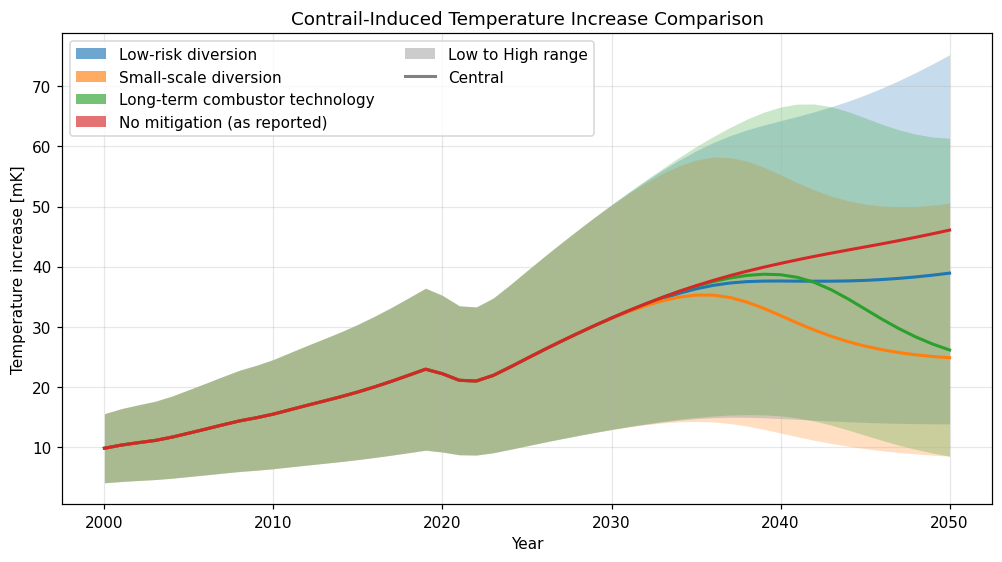

In [19]:
contrails.plot(
    "contrails_temperature_comparison",
    scenario_groups=groups,
    group_display="envelope",
    group_envelope_show_members=False,
    group_envelope_middle=middle,
)
plt.gcf().savefig("figures/contrails_temperature.png", dpi=150, bbox_inches="tight")

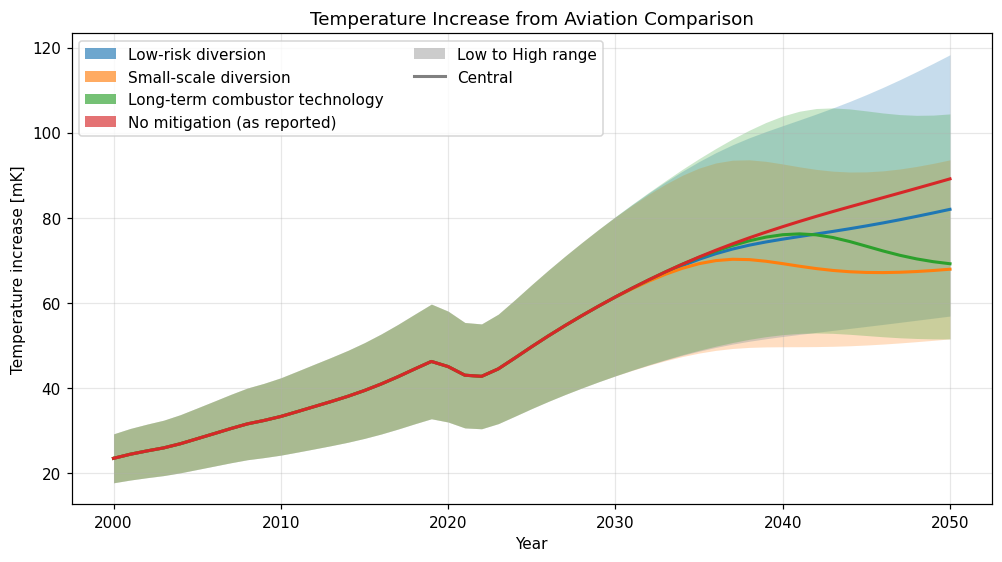

In [20]:
contrails.plot(
    "temperature_increase_comparison",
    scenario_groups=groups,
    group_display="envelope",
    group_envelope_show_members=False,
    group_envelope_middle=middle,
)
plt.gcf().savefig("figures/temperature_increase.png", dpi=150, bbox_inches="tight")

### The trade-off

Diversion buys contrail reduction by flying further, so it burns more fuel. That is why
`low-risk` exists as a separate strategy: it targets only the flights where the benefit is
largest, at almost no fuel cost.

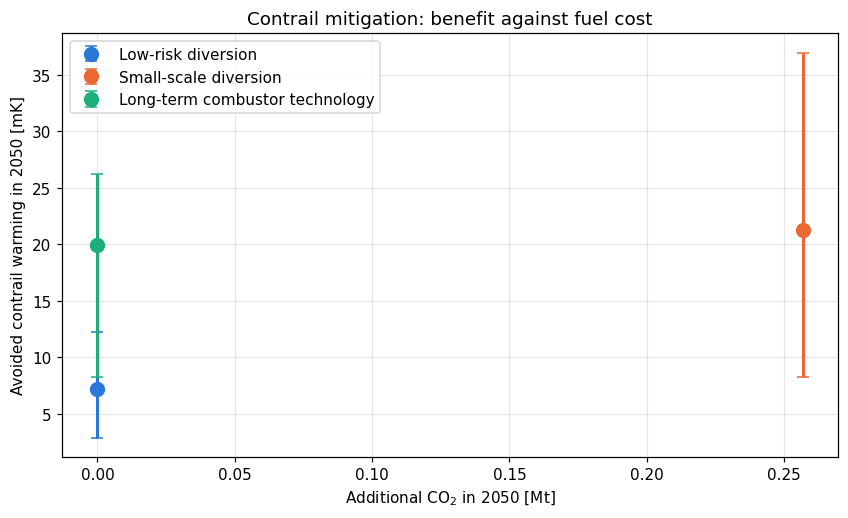

In [21]:
FAMILY_COLORS = {
    "low_risk": MECHANISM_COLORS["co2"],
    "small_scale": MECHANISM_COLORS["contrails"],
    "long_term_tech": MECHANISM_COLORS["nox"],
}


def co2_2050(name):
    frame = variant_vectors[name]
    return frame["co2_emissions_passenger"].loc[2050] + frame["co2_emissions_freight"].loc[2050]


base_contrails = variant_climate[BASELINE][T_CONTRAILS].loc[2050]
base_total = variant_climate[BASELINE][T].loc[2050]
base_co2 = co2_2050(BASELINE)

fig, ax = plt.subplots(figsize=(7.6, 4.6), layout="constrained")


def avoided_mK(family_label, level, band_key):
    """Contrail warming avoided in 2050, against the no-mitigation run at the same band."""
    reference = baseline_by_band[band_key][T_CONTRAILS].loc[2050]
    variant = variant_climate[variant_name(family_label, level)][T_CONTRAILS].loc[2050]
    return 1000 * (reference - variant)


for key, family in families.items():
    central = variant_name(family["label"], "Central")
    avoided = avoided_mK(family["label"], "Central", "central")
    # The bar spans the Low band (least warming avoided) to the High band (most). That
    # ordering is not the mitigation strength: the High band applies the *weakest* gain, but
    # it starts from far more contrail warming, and the larger baseline wins. Avoidance is
    # worth more, in absolute mK, precisely where contrails turn out to be worse.
    lower = avoided_mK(family["label"], "Low", "low")
    upper = avoided_mK(family["label"], "High", "high")
    ax.errorbar(
        co2_2050(central) - base_co2,
        avoided,
        yerr=[[avoided - lower], [upper - avoided]],
        fmt="o",
        markersize=9,
        color=FAMILY_COLORS[key],
        ecolor=FAMILY_COLORS[key],
        elinewidth=2,
        capsize=4,
        zorder=3,
        label=family["label"],
    )

ax.set_xlabel("Additional CO$_2$ in 2050 [Mt]")
ax.set_ylabel("Avoided contrail warming in 2050 [mK]")
ax.set_title("Contrail mitigation: benefit against fuel cost")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [22]:
rows = []
for key, family in families.items():
    entry = {"strategy": family["label"]}
    for level in LEVELS:
        name = variant_name(family["label"], level)
        entry[f"contrail warming {level} [mK]"] = (
            1000 * variant_climate[name][T_CONTRAILS].loc[2050]
        )
    central = variant_name(family["label"], "Central")
    total = variant_climate[central][T].loc[2050]
    entry["total warming [mK]"] = 1000 * total
    entry["total reduction [%]"] = 100 * (1 - total / base_total)
    entry["CO2 penalty [%]"] = 100 * (co2_2050(central) / base_co2 - 1)
    rows.append(entry)

summary = pd.DataFrame(rows).set_index("strategy")
print(
    f"baseline: contrail warming {1000 * base_contrails:.1f} mK, "
    f"total {1000 * base_total:.1f} mK, CO2 {base_co2:.1f} Mt"
)
display(summary.round(3))

baseline: contrail warming 46.1 mK, total 89.1 mK, CO2 644.3 Mt

,contrail warming Low [mK],contrail warming Central [mK],contrail warming High [mK],total warming [mK],total reduction [%],CO2 penalty [%]
strategy,,,,,,
Low-risk diversion,13.835,38.916,75.249,81.973,8.036,0.00
Small-scale diversion,8.465,24.841,50.554,67.900,23.824,0.04
Long-term combustor technology,8.459,26.130,61.343,69.186,22.382,0.00


In [23]:
central_values = {
    key: variant_climate[variant_name(family["label"], "Central")][T_CONTRAILS].loc[2050]
    for key, family in families.items()
}
for key, value in central_values.items():
    assert value < base_contrails, f"{key} does not reduce contrail warming"
assert central_values["small_scale"] < central_values["low_risk"], (
    "small-scale diversion is not stronger than the low-risk subset it contains"
)
for key, family in families.items():
    low = variant_climate[variant_name(family["label"], "Low")][T_CONTRAILS]
    high = variant_climate[variant_name(family["label"], "High")][T_CONTRAILS]
    # Levels are named by climate impact, so "Low" is the low-warming end: it carries both the
    # strongest mitigation and the smallest contrail sensitivity, and must sit below "High".
    assert (low.loc[2024:2050] <= high.loc[2024:2050] + 1e-12).all(), (
        f"{key}: the Low/High envelope crosses itself"
    )
print(
    "PASS - every strategy reduces contrail warming, diversion strengthens with scope, "
    "and every envelope is well formed"
)

PASS - every strategy reduces contrail warming, diversion strengthens with scope, and every envelope is well formed

### Timing beats ultimate effectiveness on a 2050 horizon

The ordering of the two single interventions is not the ordering of their headline numbers:
combustor technology is the stronger measure but starts five years later, and on a 2050 horizon
that is enough to reverse the ranking.

In [24]:
rows = []
for key in ("small_scale", "long_term_tech"):
    family = families[key]
    name = variant_name(family["label"], "Central")
    removed = (
        variant_climate[BASELINE]["contrails_erf"].loc[2024:2050]
        - variant_climate[name]["contrails_erf"].loc[2024:2050]
    ).sum()
    rows.append(
        {
            "strategy": family["label"],
            "start": int(family["levels"]["Central"]["operations_contrails_start_year"]),
            "final reduction [%]": family["levels"]["Central"]["operations_contrails_final_gain"],
            "reduction reached by 2050 [%]": variant_vectors[name]["operations_contrails_gain"].loc[
                2050
            ],
            "cumulative ERF removed [W/m2-yr]": removed,
            "contrail warming 2050 [mK]": 1000 * variant_climate[name][T_CONTRAILS].loc[2050],
        }
    )
timing = pd.DataFrame(rows).set_index("strategy")
display(timing.round(3))

stronger = timing["final reduction [%]"].idxmax()
cooler = timing["contrail warming 2050 [mK]"].idxmin()
print(f"largest final reduction : {stronger}")
print(f"least warming in 2050   : {cooler}")
assert stronger != cooler, "the timing effect has disappeared; the note above no longer applies"
print("PASS - the stronger measure is not the one that delivers most by 2050")

,start,final reduction [%],reduction reached by 2050 [%],cumulative ERF removed [W/m2-yr],contrail warming 2050 [mK]
strategy,,,,,
Small-scale diversion,2030,59.3,59.210,0.622,24.841
Long-term combustor technology,2035,68.8,67.424,0.452,26.130


largest final reduction : Long-term combustor technology

least warming in 2050   : Small-scale diversion

PASS - the stronger measure is not the one that delivers most by 2050

### The fuel penalty is real, and amplified by the SAF mandates

`low-risk` and `small-scale` start in the same year and differ only in how much diverting they
do, so the difference between them isolates the fuel penalty. CO₂ rises by *more* than energy,
because under a fixed-quantity SAF mandate the marginal fuel is fossil kerosene.

In [25]:
penalty_free = variant_name(families["low_risk"]["label"], "Central")
with_penalty = variant_name(families["small_scale"]["label"], "Central")


def totals(name):
    frame = variant_vectors[name]
    co2 = frame["co2_emissions_passenger"].loc[2050] + frame["co2_emissions_freight"].loc[2050]
    return co2, frame["energy_consumption"].loc[2050]


co2_free, energy_free = totals(penalty_free)
co2_penalised, energy_penalised = totals(with_penalty)

parameter = variant_vectors[with_penalty]["operations_contrails_overconsumption"].loc[2050]
energy_increase = 100 * (energy_penalised / energy_free - 1)
co2_increase = 100 * (co2_penalised / co2_free - 1)

print(f"overconsumption parameter at 2050 : {parameter:.6f} %")
print(f"observed energy increase          : {energy_increase:.6f} %")
print(f"observed CO2 increase             : {co2_increase:.6f} %")
print(f"amplification (CO2 / energy)      : {co2_increase / energy_increase:.2f}x")

assert abs(energy_increase - parameter) < 1e-6, (
    "the contrail-avoidance fuel penalty does not reach energy consumption"
)
assert co2_increase > energy_increase, (
    "the CO2 penalty is not amplified; the marginal fuel is no longer fossil"
)

mean_ef = variant_vectors[with_penalty]["co2_per_energy_mean"].loc[2050]
print(f"fleet-mean emission factor 2050   : {mean_ef:.2f} gCO2/MJ")
print(
    f"implied marginal emission factor  : {mean_ef * co2_increase / energy_increase:.2f} "
    f"gCO2/MJ  (kerosene is 88.7)"
)
print("PASS - the fuel penalty propagates, and the SAF mandate amplifies its CO2 cost")

overconsumption parameter at 2050 : 0.013979 %

observed energy increase          : 0.013979 %

observed CO2 increase             : 0.039841 %

amplification (CO2 / energy)      : 2.85x

fleet-mean emission factor 2050   : 31.13 gCO2/MJ

implied marginal emission factor  : 88.72 gCO2/MJ  (kerosene is 88.7)

PASS - the fuel penalty propagates, and the SAF mandate amplifies its CO2 cost

In [26]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals(), force_cleanup=False)